In [35]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
from dct import create_dct_basis
%matplotlib inline

# Image Compression

We can also apply the DCT to compress images as well.  Here we have an $8 \times 8$ image that we will attempt to compress with DCT.  Note that the pixel values range from $\left[0, 1\right]$, but we have colored it blue and orange for added emphasis.

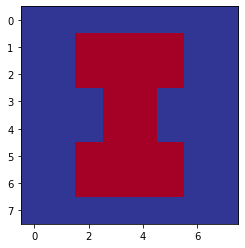

In [36]:
N = 8
block_i = np.ones((N, N))
block_i[1:-1, 3:5] = 0
block_i[1:3, 2:6] = 0
block_i[-3:-1, 2:6] = 0
plt.imshow(block_i, cmap="RdYlBu")

In [37]:
D = create_dct_basis(N)

How can we actually transform into the DCT basis here?  If we imagine the matrix `block_i` above as a linear transformation from and to the standard basis:
$$ {\bf I}_{\mathcal{E}, \mathcal{E}} $$
We can write the equivalent transformation from and to the DCT basis as:
$$ {\bf I}_{\mathcal{D}, \mathcal{D}} = {\bf D}^T {\bf I}_{\mathcal{E}, \mathcal{E}} {\bf D} $$

**Check your answers!**

Using this, convert the matrix `block_i` into the DCT frequency space and save as `freq_i`.

In [38]:
#grade (enter your code in this cell - DO NOT DELETE THIS LINE) 
freq_i = np.transpose(D) @ block_i @ D

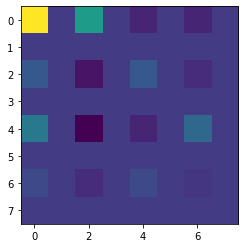

In [39]:
plt.imshow(freq_i)

Now that we have converted into the frequency space, "compress" `freq_i` by looping through the entries and removing any with an absolute value less than `tol = 0.50`.

**Check your answers!**

Save your compressed result in the variable `comp_freq` (remember to not override the values in `freq_i`!). Count the number of entries removed and store it as `removed_elems`. 

In [40]:
tol = 0.5

In [41]:
#grade (enter your code in this cell - DO NOT DELETE THIS LINE) 
comp_freq = freq_i.copy()
y, x = comp_freq.shape
removed_elems = 0
for i in range(y):
    for j in range(x):
        if (np.abs(comp_freq[i][j]) < tol):
            comp_freq[i][j] = 0
            removed_elems += 1
        

Print this value to get an idea of the rate of compression here.

In [42]:
print(f"removed {removed_elems} / {8 ** 2} entries")

removed 55 / 64 entries


**Check your answers!**

Convert `comp_freq` back into the standard basis, and save your result as `comp_i`.

In [43]:
#grade (enter your code in this cell - DO NOT DELETE THIS LINE) 
comp_i = D @ comp_freq @ np.transpose(D)

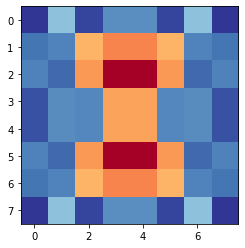

In [44]:
plt.imshow(comp_i, cmap="RdYlBu")

### Compressing Alma

This sort of image compression can be scaled up to much larger images than $8 \times 8$ using the "sectioning" or "chunking" technique discussed earlier for audio compression.  We can break an image apart into $8 \times 8$ chunks and then perform DCT compression on those.  This is in fact how the JPEG standard works.

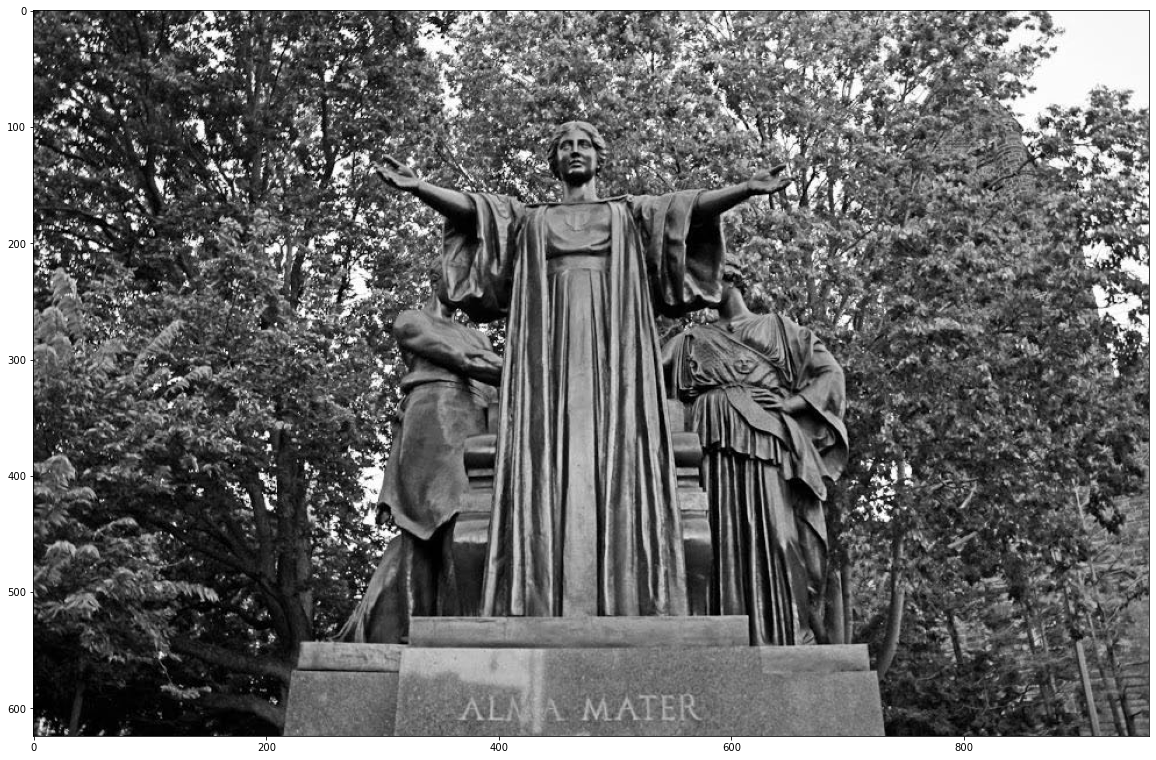

In [45]:
alma = plt.imread("alma.jpg")[:624,:,0]
plt.figure(figsize=(20,20))
plt.imshow(alma, cmap="gray")

Note that all pixel values of the image are integers between 0 and 255:

In [46]:
alma.max()

255

In [47]:
alma.min()

0

In [48]:
alma.shape

(624, 960)

First we create the DCT basis for the chunks:

In [49]:
N = 8
D2 = create_dct_basis(N)

**Check your answers!**

We provide you with the following starter code. For each `chunk`:

- Convert it to the DCT basis.


- "Drop" the frequencies with smaller contribution. Here we will set to zero all entries such that the absolute value is smaller than a tolerance `tol`. The tolerance for each chunk will be computed as 10% of the largest value of the chunk (in magnitude from the DCT basis representation).


- Convert it back to standard basis.


- Store the final "compressed" image as `alma_comp`.


- After the DCT transformations, you may find that the image values no longer lie between `0` and `255`. Use [`np.clip()`](https://numpy.org/doc/stable/reference/generated/numpy.clip.html) to correct the values back into that range.

In [50]:
#grade (enter your code in this cell - DO NOT DELETE THIS LINE) 
alma_comp = np.zeros_like(alma)

for u in range(0, alma.shape[0], N):
    for v in range(0, alma.shape[1], N):
        # Get get subimages of the alma image, and store them as chunk
        chunk = alma[u:u+N, v:v+N].copy() 
        
        # Convert to DCT basis
        chunk_dct = np.transpose(D2) @ chunk @ D2 #CHANGE THIS
        
        # Get the tolerance
        tol = 0.1*np.max(np.abs(chunk_dct))
        
        # Change to zero all the entries with value smaller than the tolerance
        chunk_dct[np.abs(chunk_dct) < tol] = 0 #every element of chunk_dct that meets the criteria in the brakets is replaced with zero
        
        # Convert back to standard basis
        chunk_comp = D2 @ chunk_dct @ np.transpose(D2) #CHANGE THIS
        
        # Store result as alma_comp
        alma_comp[u:u+N, v:v+N] = np.clip(chunk_comp.copy(), 0, 255)


Plot your image.  How does it compare to the original Alma image above?

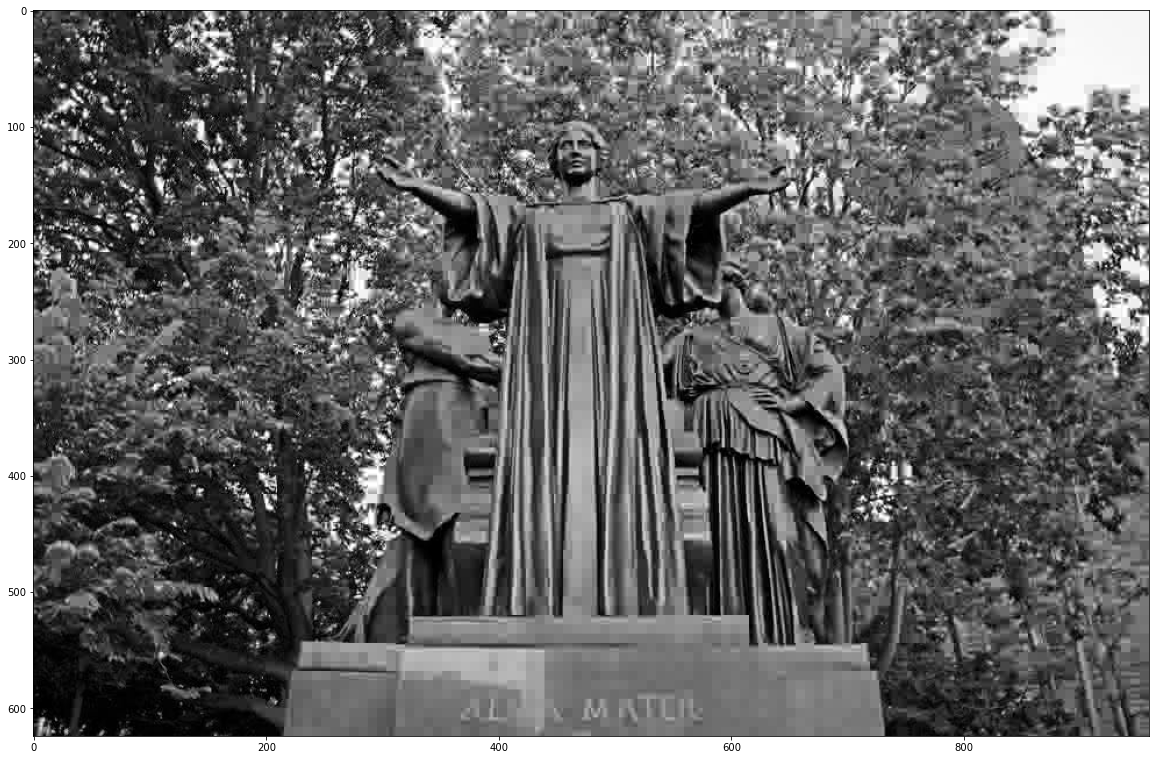

In [51]:
plt.figure(figsize=(20,20))
plt.imshow(alma_comp, cmap="gray")